# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [36]:
import pandas as pd 
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "data evaluacion"
file_name = "athlete_events.csv"
file_path = DATA_DIR / file_name

df = pd.read_csv(file_path, na_values= ' ')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [37]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [38]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


In [39]:
df = df.drop(
    columns= [
        'ID', #Clave primaria
        'Team', #Redundancia
        'Games', #Redundancia
    ]
)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Name    271116 non-null  object 
 1   Sex     271116 non-null  object 
 2   Age     261642 non-null  float64
 3   Height  210945 non-null  float64
 4   Weight  208241 non-null  float64
 5   NOC     271116 non-null  object 
 6   Year    271116 non-null  int64  
 7   Season  271116 non-null  object 
 8   City    271116 non-null  object 
 9   Sport   271116 non-null  object 
 10  Event   271116 non-null  object 
 11  Medal   39783 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 24.8+ MB


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [41]:
cat_vars = df.select_dtypes(include='object').columns.to_list()

cat_vars

['Name', 'Sex', 'NOC', 'Season', 'City', 'Sport', 'Event', 'Medal']

In [42]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable Name es: 
 Name
Robert Tait McKenzie          58
Heikki Ilmari Savolainen      39
Joseph "Josy" Stoffel         38
Ioannis Theofilakis           36
Takashi Ono                   33
                              ..
James Francis "Jim" Zylker     1
Yury Ivanovich Zyabrev         1
Victor Andrew "Vic" Zwolak     1
Werner Zwimpfer                1
Edgar Lindenau Aabye           1
Name: count, Length: 134732, dtype: int64 

El conteo de la variable Sex es: 
 Sex
M    196594
F     74522
Name: count, dtype: int64 

El conteo de la variable NOC es: 
 NOC
USA    18853
FRA    12758
GBR    12256
ITA    10715
GER     9830
       ...  
YMD        5
SSD        3
NBO        2
UNK        2
NFL        1
Name: count, Length: 230, dtype: int64 

El conteo de la variable Season es: 
 Season
Summer    222552
Winter     48564
Name: count, dtype: int64 

El conteo de la variable City es: 
 City
London                    22426
Athina                    15556
Sydney                    

**Variables nominales**

- Name (Alta cardinalidad) -> Combinación de categorías 
- Sex (binaria) -> OneHotEncoder con if_binary=True
- NOC -> Combinación de categorías
- Season (binaria) -> OneHotEncoder con if_binary=True
- City -> Combinación de categorías
- Sport -> Combinación de categorías
- Event -> Combinación de categorías

**Variabes ordinales**

- Medal -> OrdinalEncoder

**Variables con categorías atípicas**
- Algunos nombres aparecen solo una vez

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Year'}>]], dtype=object)

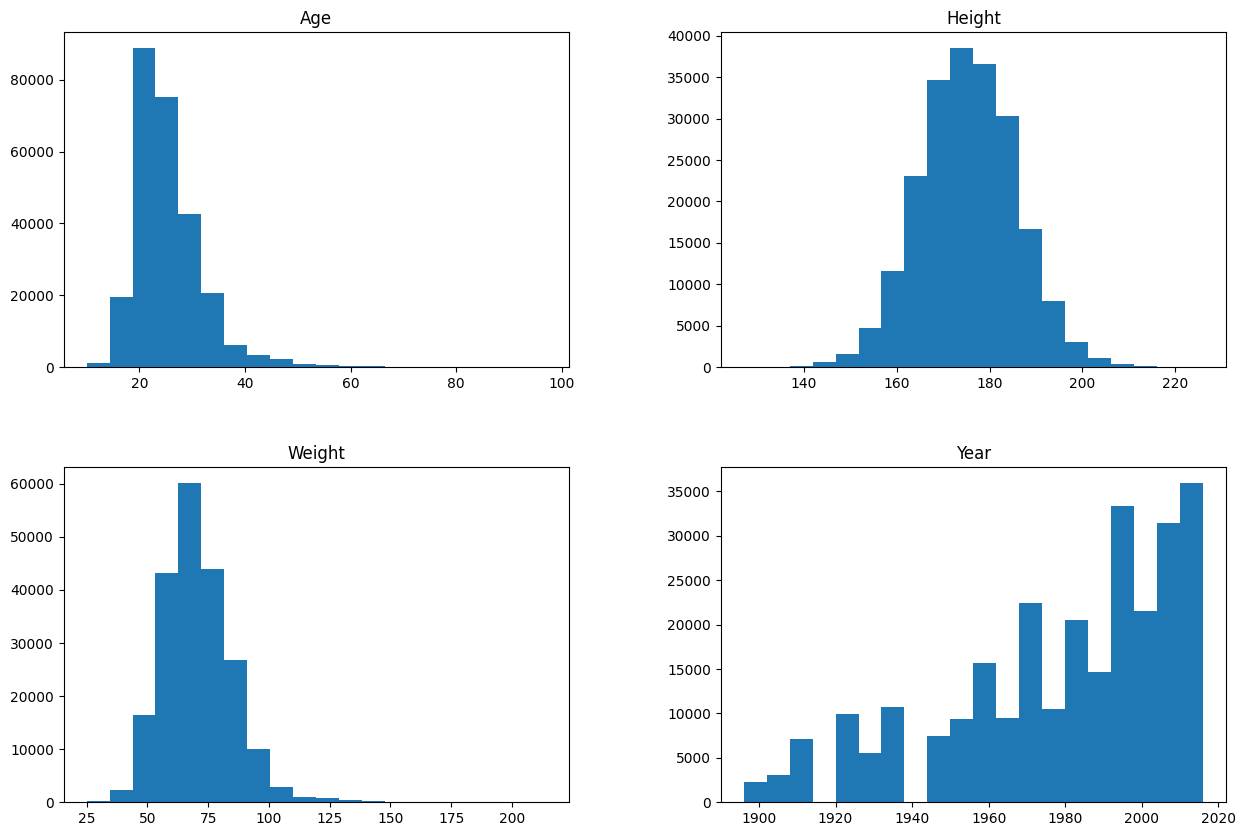

In [43]:
df.hist(
    bins=20,
    grid=False,
    figsize=(15,10)
)

Age          Axes(0.125,0.653529;0.227941x0.226471)
Height    Axes(0.398529,0.653529;0.227941x0.226471)
Weight    Axes(0.672059,0.653529;0.227941x0.226471)
Year         Axes(0.125,0.381765;0.227941x0.226471)
dtype: object

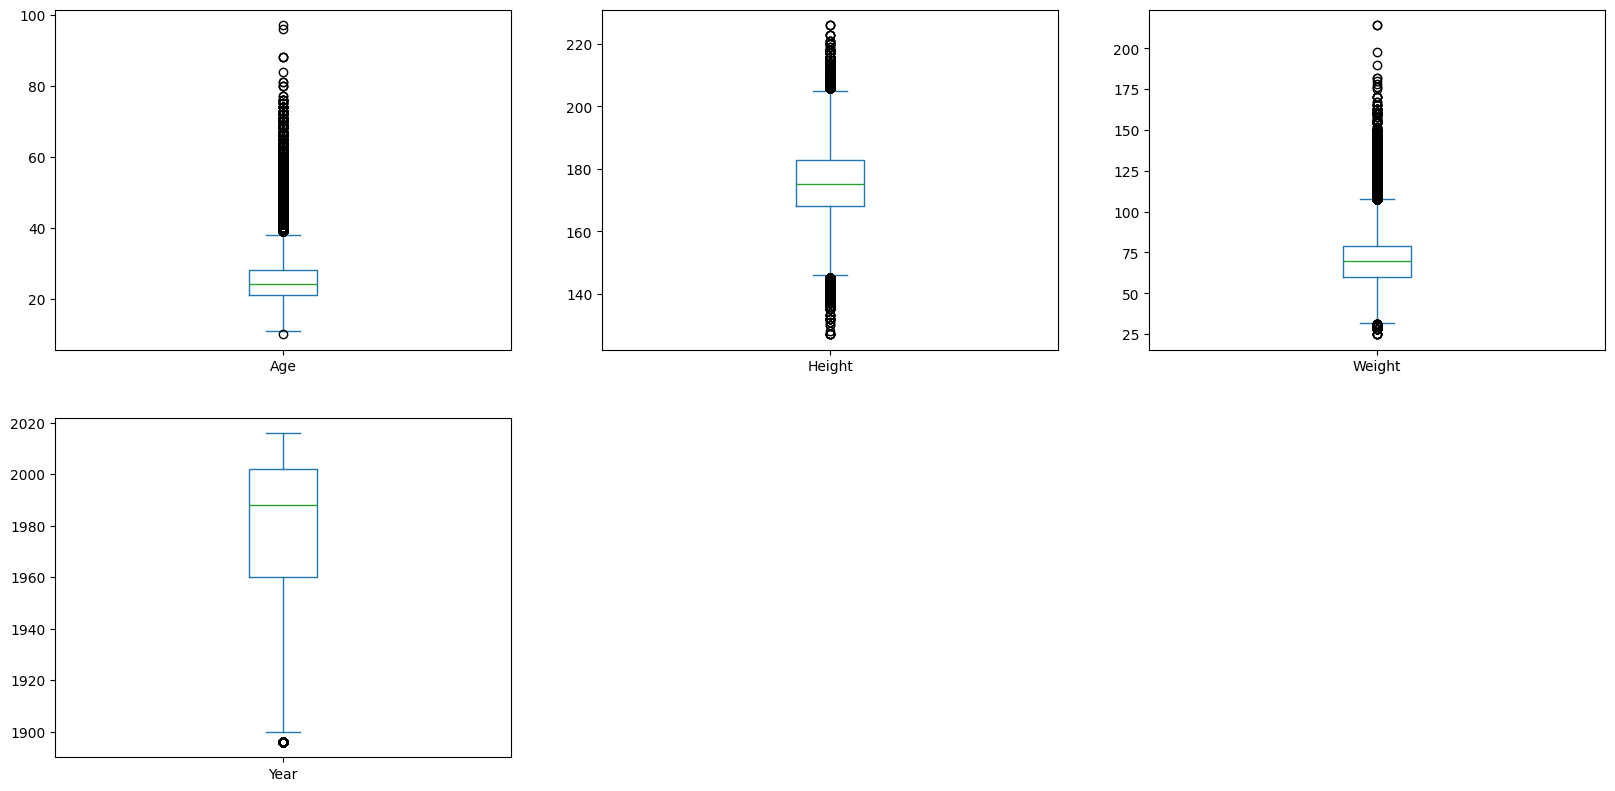

In [44]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

**Variables aproximadamente normales**

- Height
- Age 

**Variables con valores atípicos**

Todas las variables menos year tienen bastantes valores atípicos, year también los tiene pero no son tanto como podemos ver en el diagrama de cajas y bigotes

- Age -> StandardScaler()
- Height -> StandardScaler()
- Weight (Variable que queremos predecir)
- Year -> MinMaxScaler()


Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

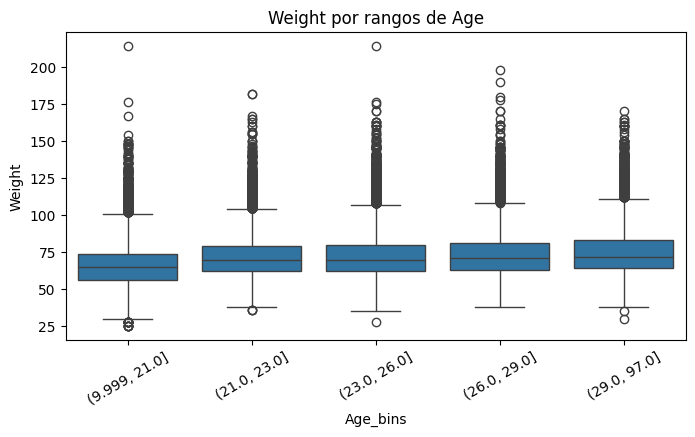

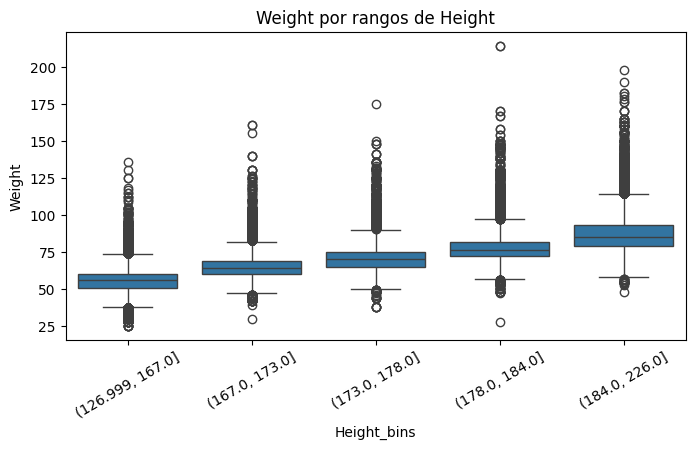

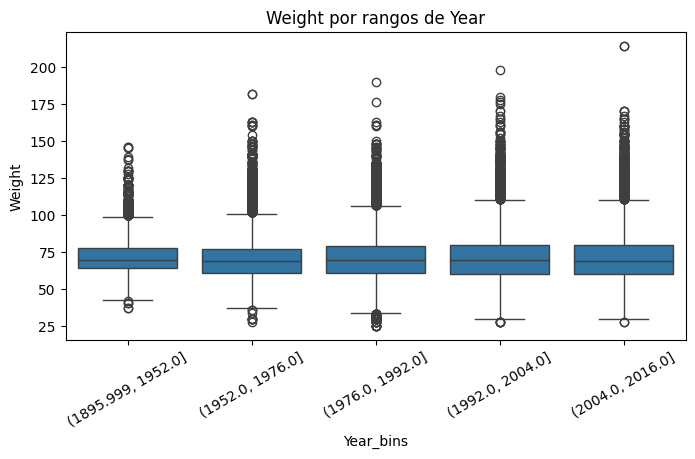

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

predictors = [col for col in df.select_dtypes(include='number').columns if col != 'Weight']

for var in predictors:
    plt.figure(figsize=(8, 4))
    
    df[f'{var}_bins'] = pd.qcut(df[var], q=5, duplicates='drop')
    
    sns.boxplot(data=df, x=f'{var}_bins', y='Weight')
    plt.xticks(rotation=30)
    plt.title(f'Weight por rangos de {var}')
    plt.show()
    
   
    df.drop(columns=[f'{var}_bins'], inplace=True)

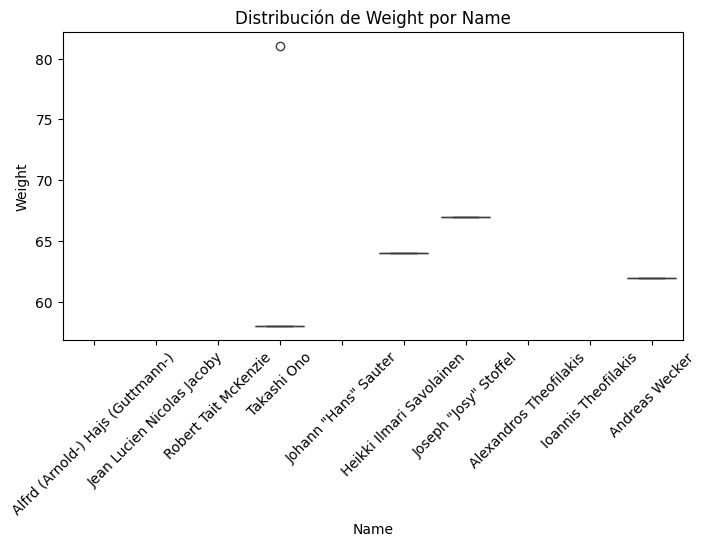

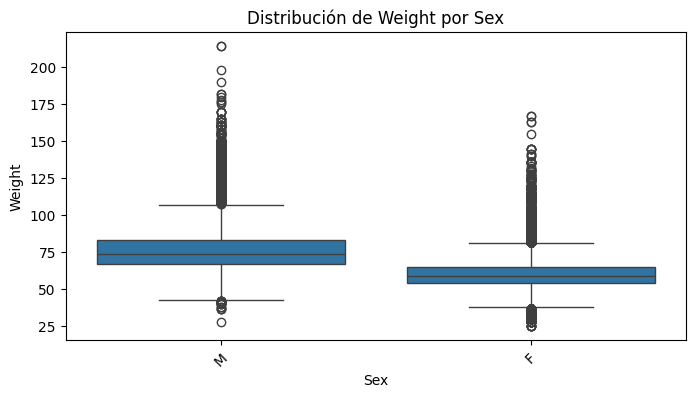

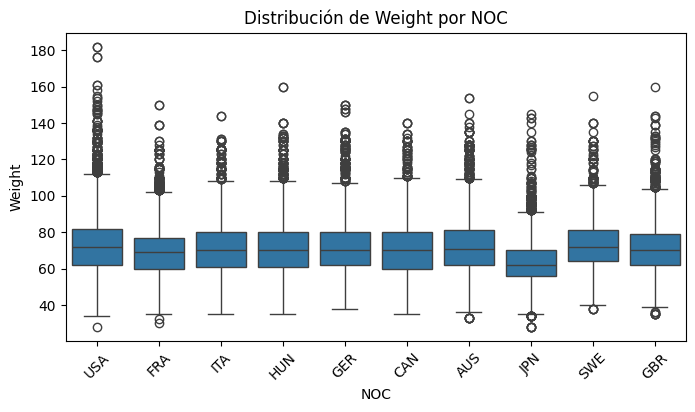

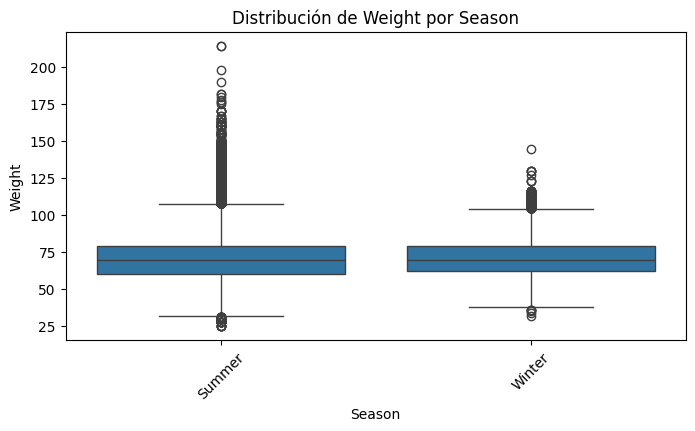

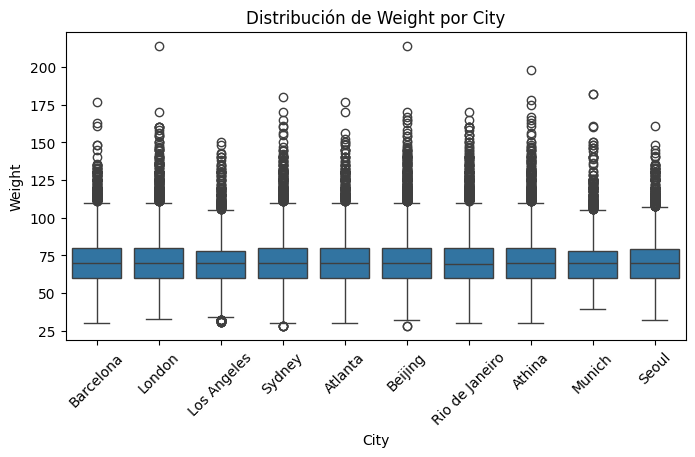

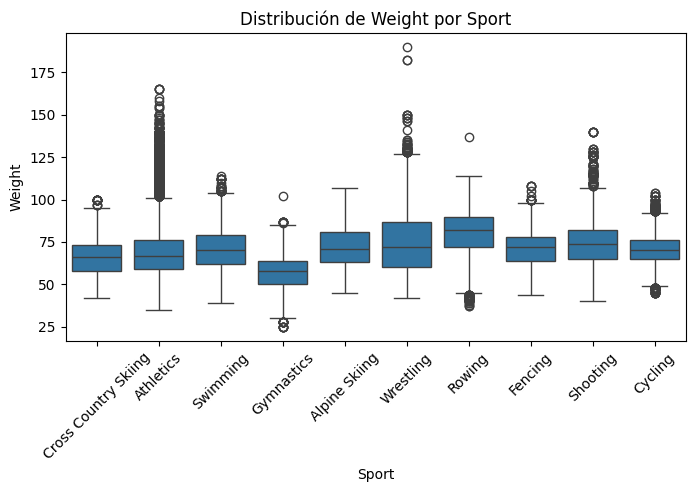

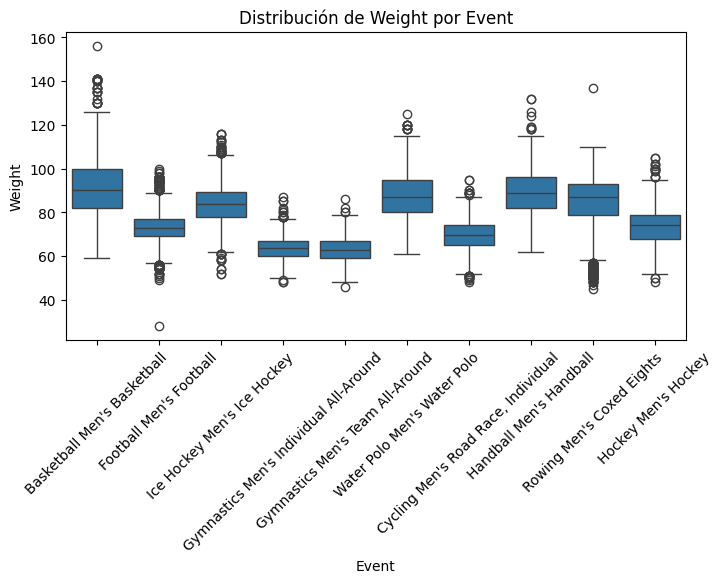

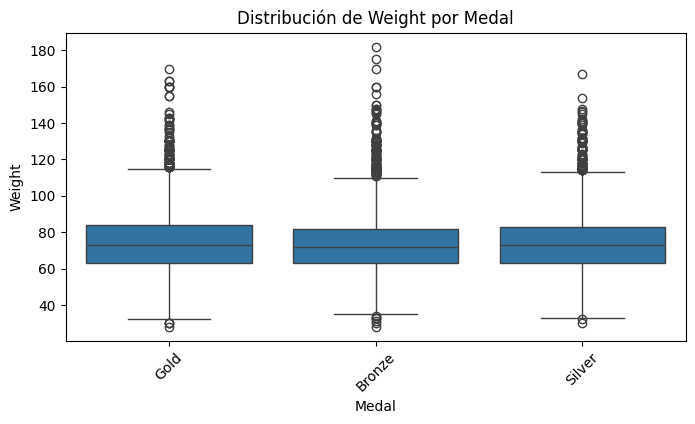

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

for var in cat_vars:
    #Tomamos las Top 10 porque hay muchas variables con categorías únicas
    top_cats = df[var].value_counts().head(10).index
    df_filtered = df[df[var].isin(top_cats)]

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_filtered, x=var, y='Weight')
    plt.title(f'Distribución de Weight por {var}')
    plt.xticks(rotation=45)
    plt.show()

**Variables cuantitativas**
- Height es una buena predictora

**Variables categóricas**
- Sex es buena predictora
- Event es buena predictora
- Sport es buena predictora

El resto no, realmente no hay variación entre las medianas

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [47]:
from sklearn.model_selection import train_test_split

#Limpiamos Weight porque tiene valores nulos
df_clean = df.dropna(subset=['Weight'])

X = df_clean.drop(['Weight'], axis=1)

y = df_clean['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (166592, 11)
Tamaño del conjunto de prueba es: (41649, 11)


In [48]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


orden = ['NA', 'Bronze', 'Silver', 'Gold']
ord_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
    ('ordinal', OrdinalEncoder(categories=[orden], handle_unknown='use_encoded_value', unknown_value=-1))
])


sex_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='if_binary', sparse_output=False))
])


multi_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(max_categories=10, handle_unknown='infrequent_if_exist', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('height', num_pipeline, ['Height']),
        ('medal', ord_pipeline, ['Medal']),
        ('sex', sex_pipeline, ['Sex']),
        ('multi_cat', multi_cat_pipeline, ['Event', 'Sport'])
    ],
    remainder='drop'
)

preprocessor

,transformers,"[('height', ...), ('medal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [49]:
from sklearn.linear_model import Ridge

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

In [50]:
pipeline.fit(X_train, y_train)

print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.6748821500874075
Exactitud del modelo en el conjunto de prueba: 0.6703938315040449


In [51]:
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['height__Height', 'medal__Medal', 'sex__Sex_M',
       "multi_cat__Event_Athletics Men's Marathon",
       "multi_cat__Event_Basketball Men's Basketball",
       "multi_cat__Event_Cycling Men's Road Race, Individual",
       "multi_cat__Event_Football Men's Football",
       "multi_cat__Event_Handball Men's Handball",
       "multi_cat__Event_Hockey Men's Hockey",
       "multi_cat__Event_Ice Hockey Men's Ice Hockey",
       "multi_cat__Event_Volleyball Men's Volleyball",
       "multi_cat__Event_Water Polo Men's Water Polo",
       'multi_cat__Event_infrequent_sklearn',
       'multi_cat__Sport_Alpine Skiing', 'multi_cat__Sport_Athletics',
       'multi_cat__Sport_Cross Country Skiing',
       'multi_cat__Sport_Cycling', 'multi_cat__Sport_Fencing',
       'multi_cat__Sport_Gymnastics', 'multi_cat__Sport_Rowing',
       'multi_cat__Sport_Shooting', 'multi_cat__Sport_Swimming',
       'multi_cat__Sport_infrequent_sklearn'], dtype=object)

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import Ridge


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

orden = ['NA', 'Bronze', 'Silver', 'Gold']
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
    ('ordinal', OrdinalEncoder(
        categories=[orden], 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    ))
])

sex_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='if_binary', sparse_output=False))
])

multi_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(max_categories=10, handle_unknown='infrequent_if_exist', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, ['Height', 'Age']),
        ('medal', ord_pipeline, ['Medal']),
        ('sex', sex_pipeline, ['Sex']),
        ('multi_cat', multi_cat_pipeline, ['Event', 'Sport', 'NOC'])
    ],
    remainder='drop'
)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])


pipeline.fit(X_train, y_train)

print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.6792040938310051
Exactitud del modelo en el conjunto de prueba: 0.6737782403363306


In [53]:
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['num__Height', 'num__Age', 'medal__Medal', 'sex__Sex_M',
       "multi_cat__Event_Athletics Men's Marathon",
       "multi_cat__Event_Basketball Men's Basketball",
       "multi_cat__Event_Cycling Men's Road Race, Individual",
       "multi_cat__Event_Football Men's Football",
       "multi_cat__Event_Handball Men's Handball",
       "multi_cat__Event_Hockey Men's Hockey",
       "multi_cat__Event_Ice Hockey Men's Ice Hockey",
       "multi_cat__Event_Volleyball Men's Volleyball",
       "multi_cat__Event_Water Polo Men's Water Polo",
       'multi_cat__Event_infrequent_sklearn',
       'multi_cat__Sport_Alpine Skiing', 'multi_cat__Sport_Athletics',
       'multi_cat__Sport_Cross Country Skiing',
       'multi_cat__Sport_Cycling', 'multi_cat__Sport_Fencing',
       'multi_cat__Sport_Gymnastics', 'multi_cat__Sport_Rowing',
       'multi_cat__Sport_Shooting', 'multi_cat__Sport_Swimming',
       'multi_cat__Sport_infrequent_sklearn', 'multi_cat__NOC_AUS',
       'multi_cat__NOC_CAN